In [1]:
from scoresbibm.src.utils.data_utils import query, get_summary_df,load_model
from scoresbibm.src.utils.plot import plot_metric_by_num_simulations, use_style,multi_plot

from scoresbibm.src.tasks.unstructured_tasks import SIRTask

import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

In [2]:
task = SIRTask()

observation_generator = task.get_observation_generator()
reference_sampler = task.get_reference_sampler()
observation_stream = observation_generator(jax.random.PRNGKey(5))

In [3]:
#model = load_model("../../results/lotka_volterra", 0)

In [4]:
condition_mask, x_o, theta_o, meta_data, node_id = next(observation_stream)
print(condition_mask.shape, x_o.shape, meta_data.shape, node_id.shape)

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False]


In [5]:
data = task.get_data(1000, rng=jax.random.PRNGKey(5))

In [13]:
data["theta"].devices()

{cuda(id=0)}

In [7]:
batch_sampler = task.get_batch_sampler()

In [11]:
task.get_eval_node_id().shape

(82,)

In [8]:
?batch_sampler

Signature:     
batch_sampler(
    key,
    batch_size,
    data,
    node_id,
    meta_data=None,
    num_devices=1,
)
Call signature: batch_sampler(*args, **kwargs)
Type:           PjitFunction
String form:    <PjitFunction of <function UnstructuredTask.get_batch_sampler.<locals>.batch_sampler at 0x7f57bf201080>>
File:           /mnt/qb/work/macke/mgloeckler90/probjax/scoresbibm/src/tasks/unstructured_tasks.py

In [6]:
thetas = theta_o[:4]
predator_observed = theta_o[4:4 + 20]
prey_observed = theta_o[4 + 20:]
observed_time1 = meta_data[4:4 + 20]
observed_time2 = meta_data[4 + 20:]

In [7]:
predator_observed_smaller10 = predator_observed[observed_time1 < 6][::5]
prey_observed_smaller10 = prey_observed[observed_time1 < 6][::5]
observed_time1_smaller10 = observed_time1[observed_time1 < 6][::5]
observed_time2_smaller10 = observed_time2[observed_time1 < 6][::5]

In [8]:
num_time_points = 100
node_id = jnp.array([0,1,2,3] + [4]*num_time_points + [5]*num_time_points)
time_grid = jnp.linspace(0, 6, num_time_points)
index1 = jnp.searchsorted(time_grid,observed_time1_smaller10)
index2 = jnp.searchsorted(time_grid,observed_time2_smaller10)
time_grid = time_grid.at[index1].set(observed_time1_smaller10)
time_grid = time_grid.at[index2].set(observed_time2_smaller10)
meta_data = jnp.concatenate([jnp.full((4,), jnp.nan), time_grid,time_grid])
condition_mask_posterior = jnp.array([False]*4 + [False]*num_time_points + [False]*num_time_points)
condition_mask_posterior = condition_mask_posterior.at[4 + index1].set(True)
condition_mask_posterior = condition_mask_posterior.at[4 + num_time_points + index2].set(True)
x_o = jnp.concatenate([predator_observed_smaller10, prey_observed_smaller10])

In [10]:
posterior_and_predictive = model.sample(300, x_o=x_o, condition_mask=condition_mask_posterior, node_id=node_id, meta_data=meta_data, rng=jax.random.PRNGKey(0), return_conditioned_samples=True)

In [ ]:
thetas, predator,prey = jnp.split(posterior_and_predictive, [4,4+num_time_points], axis=1)
_,condition_mask_predator, condition_mask_prey = jnp.split(condition_mask_posterior, [4,4+num_time_points])
mean_predator = jnp.mean(predator, axis=0)[~condition_mask_predator]
q_l = jnp.percentile(predator, 0.5, axis=0)[~condition_mask_predator]
q_u = jnp.percentile(predator, 99.5, axis=0)[~condition_mask_predator]

mean_prey = jnp.mean(prey, axis=0)[~condition_mask_prey]
q_l_prey = jnp.percentile(prey, 0.5, axis=0)[~condition_mask_prey]
q_u_prey = jnp.percentile(prey, 99.5, axis=0)[~condition_mask_prey]


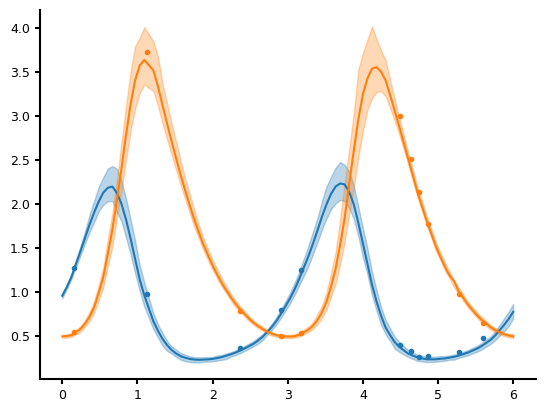

In [10]:
with use_style("pyloric"):
    
    _ = plt.scatter(observed_time1_smaller10, predator_observed_smaller10, color="C0")
    _ = plt.plot(time_grid[~condition_mask_predator], mean_predator, color="C0")
    _ = plt.fill_between(time_grid[~condition_mask_predator], q_l, q_u, alpha=0.3, color="C0")

    _ = plt.scatter(observed_time2_smaller10, prey_observed_smaller10, color="C1")
    _ = plt.plot(time_grid[~condition_mask_prey], mean_prey, color="C1")
    _ = plt.fill_between(time_grid[~condition_mask_prey], q_l_prey, q_u_prey, alpha=0.3, color="C1")


In [ ]:
posterior_samples = model.sample(1000, x_o=x_o, condition_mask=condition_mask, node_id=node_id, meta_data=meta_data, rng=jax.random.PRNGKey(0))

In [ ]:
ref_samples = reference_sampler.sample(1000, x_o=x_o, condition_mask=condition_mask, meta_data=meta_data, rng=jax.random.PRNGKey(0))

(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

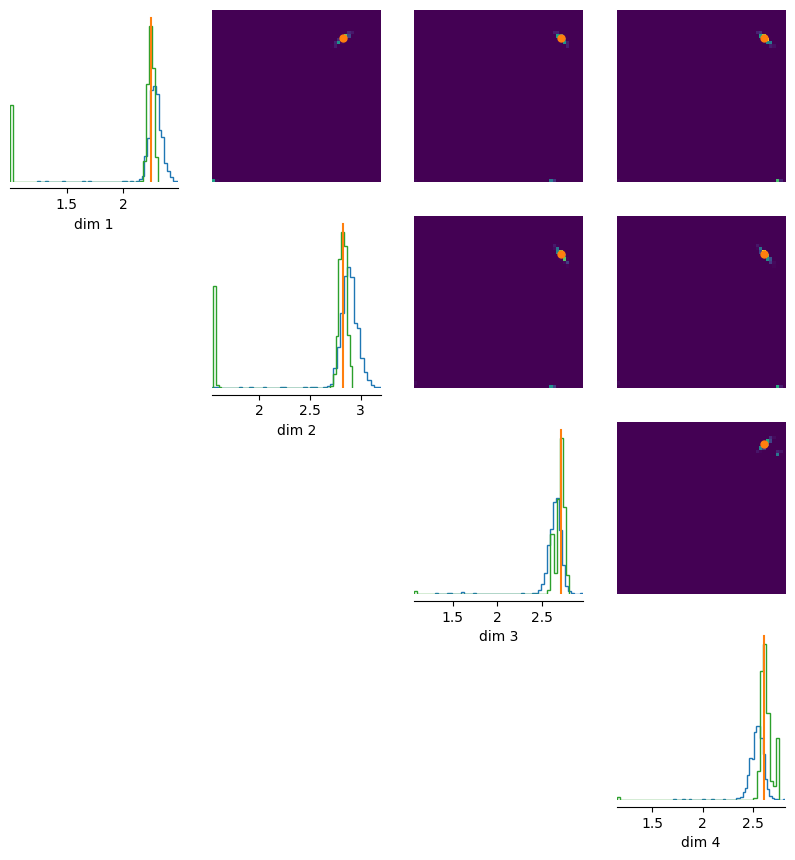

In [47]:
from sbi.analysis import pairplot
import numpy as np

pairplot([np.array(posterior_samples),np.array(ref_samples)], points=theta_o)